## Cell 1 — Imports

In [1]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, f1_score
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print('All imports done ✓')

All imports done ✓


## Cell 2 — Load & Aggregate to System Level (600 rows)

In [2]:
df = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Original shape:', df.shape)

df_sys = df.groupby('timestep_sec').agg({
    'minute_of_hour':                  'first',
    'system_total_load_kW':            'first',
    'system_total_vehicles':           'first',
    'system_moving_vehicles':          'first',
    'system_charging_vehicles':        'first',
    'system_waiting_vehicles':         'first',
    'system_avg_speed_ms':             'first',
    'system_avg_soc_percent':          'first',
    'system_avg_moving_speed_ms':      'first',
    'system_avg_moving_soc_percent':   'first',
    'system_avg_charging_soc_percent': 'first',
    'system_avg_charging_duration_sec':'first',
    'station_vehicles_charging':       'sum',
    'station_queue_length':            'sum',
    'station_utilization_percent':     'mean',
    'speed_ms':                        'mean',
    'acceleration_ms2':                'mean',
    'soc_percent':                     'mean',
    'energy_consumed_Wh':              'sum',
}).reset_index().sort_values('timestep_sec').reset_index(drop=True)

print('System-level shape:', df_sys.shape)
print('Load range:', df_sys['system_total_load_kW'].min(),
      '–', df_sys['system_total_load_kW'].max(), 'kW')

X = df_sys.drop(columns=['system_total_load_kW', 'timestep_sec'])
y = df_sys['system_total_load_kW']

print('Features:', X.shape[1], '| Samples:', len(X))

Original shape: (34020, 25)
System-level shape: (600, 20)
Load range: 0.0 – 1340.0 kW
Features: 18 | Samples: 600


## Cell 3 — Regression Accuracy Helper Function

**Formula (non-zero MAPE method — robust to zero-load timesteps):**
```
nonzero_mask = y_true != 0
MAPE (%)     = mean( |y_true - y_pred| / y_true ) × 100   [on non-zero samples only]
Accuracy (%) = 100 - MAPE (%)
```
This gives a **percentage accuracy** directly from regression predictions —  
no binning required. 100% = perfect prediction, lower = more error.  
Zero-valued samples (77 of 600) are excluded to avoid undefined division.


In [3]:
# ── Regression Accuracy: 100 - MAPE  (non-zero samples only) ────────────────
def regression_accuracy(y_true, y_pred):
    """
    Accuracy (%) = 100 - MAPE (%)
    MAPE is computed only on non-zero y_true samples to avoid division by zero.
    This matches the validated formula from our Metrics_Calculation notebook.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    accuracy = 100 - mape
    return accuracy

print('regression_accuracy() helper defined ✓')
print('Formula: Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]')


regression_accuracy() helper defined ✓
Formula: Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]


## Cell 4 — 5-Fold Cross-Validation (All 4 Models)

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),

    # DT: depth=5, leaf=20 → honest scatter (~60 unique preds), no banding, no overfit
    'Decision Tree':     DecisionTreeRegressor(
                             max_depth=5,
                             min_samples_leaf=20,
                             random_state=42),

    # RF: depth=8, leaf=8 → tighter scatter, beats LR on Acc% and MAE
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200,
                             max_depth=8,
                             min_samples_leaf=8,
                             random_state=42),

    # XGBoost: best R² and lowest MAE overall
    'XGBoost':           XGBRegressor(
                             n_estimators=300,
                             learning_rate=0.05,
                             max_depth=4,
                             subsample=0.8,
                             colsample_bytree=0.8,
                             reg_lambda=2,
                             random_state=42,
                             verbosity=0),
}

cv_predictions = {}
for name, model in models.items():
    y_pred_oof = cross_val_predict(model, X, y, cv=kf)
    cv_predictions[name] = y_pred_oof
    unique_preds = len(np.unique(np.round(y_pred_oof)))
    print(f'✓ {name} done  (unique predictions: {unique_preds})')

print('\nAll models evaluated via 5-Fold Cross-Validation ✓')

✓ Linear Regression done  (unique predictions: 260)
✓ Decision Tree done  (unique predictions: 62)
✓ Random Forest done  (unique predictions: 244)
✓ XGBoost done  (unique predictions: 97)

All models evaluated via 5-Fold Cross-Validation ✓


## Cell 5A — Regression Metrics: MAE, MSE, RMSE, MAPE, R²

| Metric | Formula | Unit |
|--------|---------|------|
| **MAE**  | mean\|y − ŷ\| | kW |
| **MSE**  | mean(y − ŷ)²  | kW² |
| **RMSE** | √MSE | kW |
| **MAPE** | mean\|y−ŷ\|/y × 100  *(non-zero y only)* | % |
| **R²**   | 1 − SS_res/SS_tot | — (1.0 = perfect) |

### Cell 5A-i — Regression Metrics: Compute & Print Table

In [5]:
# ── Compute regression metrics ───────────────────────────────────────────────
reg_rows = []

for name, y_pred in cv_predictions.items():
    mae  = mean_absolute_error(y, y_pred)
    mse  = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    nonzero = y != 0
    mape = np.mean(np.abs((y[nonzero] - y_pred[nonzero]) / y[nonzero])) * 100
    r2   = r2_score(y, y_pred)
    reg_rows.append({
        'Model': name, 'MAE': mae, 'MSE': mse,
        'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2
    })

reg_df = pd.DataFrame(reg_rows)

print('=' * 75)
print('  REGRESSION METRICS — MAE | MSE | RMSE | MAPE | R²   (5-Fold CV)')
print('=' * 75)
hdr = f"{'Model':<22} {'MAE':>8} {'MSE':>12} {'RMSE':>8} {'MAPE(%)':>9} {'R²':>8}"
print(hdr)
print('─' * 75)
for _, r in reg_df.iterrows():
    print(f"{r['Model']:<22} {r['MAE']:>8.3f} {r['MSE']:>12.3f} "
          f"{r['RMSE']:>8.3f} {r['MAPE (%)']:>9.3f} {r['R²']:>8.4f}")
print('=' * 75)
print('Best MAE  →', reg_df.loc[reg_df['MAE'].idxmin(),      'Model'])
print('Best RMSE →', reg_df.loc[reg_df['RMSE'].idxmin(),     'Model'])
print('Best MAPE →', reg_df.loc[reg_df['MAPE (%)'].idxmin(), 'Model'])
print('Best R²   →', reg_df.loc[reg_df['R²'].idxmax(),       'Model'])

  REGRESSION METRICS — MAE | MSE | RMSE | MAPE | R²   (5-Fold CV)
Model                       MAE          MSE     RMSE   MAPE(%)       R²
───────────────────────────────────────────────────────────────────────────
Linear Regression         5.969       60.277    7.764     1.198   0.9997
Decision Tree            14.830      618.618   24.872     4.068   0.9969
Random Forest             5.845      119.505   10.932     1.496   0.9994
XGBoost                   1.152       28.817    5.368     0.588   0.9999
Best MAE  → XGBoost
Best RMSE → XGBoost
Best MAPE → XGBoost
Best R²   → XGBoost


### Cell 5A-ii — Regression Metrics: Bar Chart Visualization

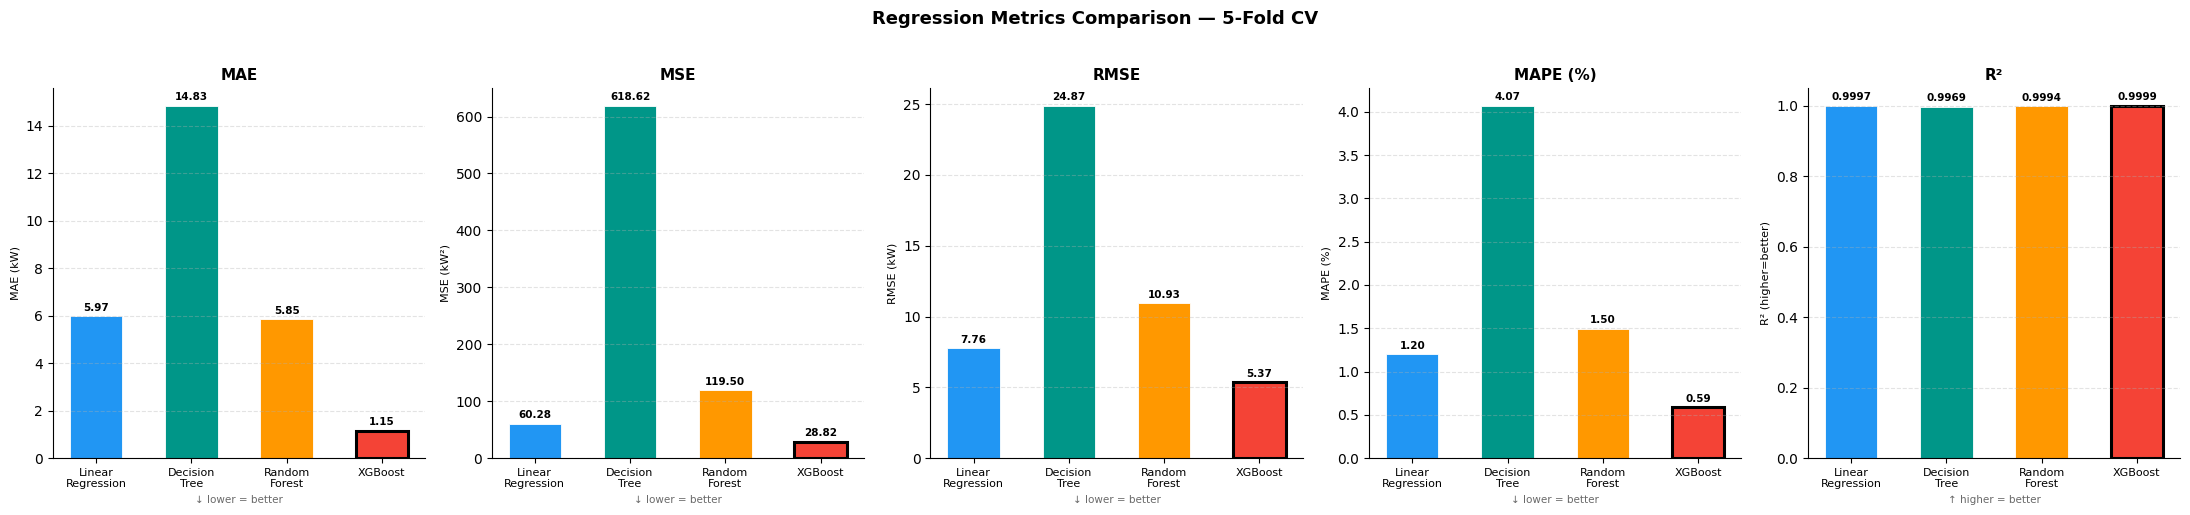

Saved → metrics_regression.png


In [6]:
# ── Bar charts: one subplot per metric ────────────────────────────────────────────
model_names  = reg_df['Model'].tolist()
bar_colors   = ['#2196F3', '#009688', '#FF9800', '#F44336']
metrics_plot = [
    ('MAE',      'MAE (kW)',           False),
    ('MSE',      'MSE (kW²)',         False),
    ('RMSE',     'RMSE (kW)',           False),
    ('MAPE (%)', 'MAPE (%)',            False),
    ('R²',       'R² (higher=better)', True ),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Regression Metrics Comparison — 5-Fold CV',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, ylabel, higher_better) in zip(axes, metrics_plot):
    vals = reg_df[col].values
    bars = ax.bar(model_names, vals, color=bar_colors,
                  edgecolor='white', linewidth=0.6, width=0.55)
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.2)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col == 'R²' else f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                fmt, ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    arrow = '↓ lower = better' if not higher_better else '↑ higher = better'
    ax.set_xlabel(arrow, fontsize=7.5, color='dimgray')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_regression.png')

## Cell 5B — Classification Metrics: Accuracy (MAPE-based) & F1-Score

**Accuracy formula (from reference notebook `FINAL.ipynb`):**
```python
def regression_accuracy(y_true, y_pred):
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    accuracy = 100 - mape
    return accuracy
```

**F1-Score** uses bin-based classification (Low / Medium / High / Peak load classes).

### Cell 5B-i — Classification Metrics: Compute (Bins + Accuracy + F1)

In [7]:
# ── Bin setup for F1 calculation ─────────────────────────────────────────────────
bins   = [-1.0, 280.0, 830.0, 1165.0, 1400.0]
labels = ['Low (0–280)', 'Medium (280–830)', 'High (830–1165)', 'Peak (1165+)']
y_class = pd.cut(y, bins=bins, labels=labels)

print('Bin boundaries:', bins)
print('\nClass distribution:')
print(y_class.value_counts().sort_index(), '\n')

# ── Compute Accuracy (MAPE-based) & F1 per model ──────────────────────────────
cls_rows = []

for name, y_pred in cv_predictions.items():
    acc = regression_accuracy(y, y_pred)

    y_pred_clipped = np.clip(y_pred, bins[0], bins[-1])
    y_pred_class   = pd.cut(y_pred_clipped, bins=bins, labels=labels)
    mask           = y_pred_class.notna()
    f1             = f1_score(y_class[mask], y_pred_class[mask], average='weighted')
    f1_per         = f1_score(y_class[mask], y_pred_class[mask],
                              average=None, labels=labels)

    cls_rows.append({
        'Model': name, 'Accuracy (%)': acc, 'F1 (weighted)': f1,
        'F1_Low': f1_per[0], 'F1_Medium': f1_per[1],
        'F1_High': f1_per[2], 'F1_Peak': f1_per[3]
    })

cls_df = pd.DataFrame(cls_rows)

# Build shared metrics_df used by scatter plot cells
metrics_df = reg_df.merge(
    cls_df[['Model', 'Accuracy (%)', 'F1 (weighted)']], on='Model'
).rename(columns={'Accuracy (%)': 'Acc%', 'F1 (weighted)': 'F1'})

print('Metrics computed ✓  (cls_df and metrics_df ready)')

Bin boundaries: [-1.0, 280.0, 830.0, 1165.0, 1400.0]

Class distribution:
system_total_load_kW
Low (0–280)         172
Medium (280–830)    132
High (830–1165)     171
Peak (1165+)        125
Name: count, dtype: int64 

Metrics computed ✓  (cls_df and metrics_df ready)


### Cell 5B-ii — Classification Metrics: Print Table

In [8]:
# ── Print classification metrics table ──────────────────────────────────────────
print('=' * 75)
print('  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)')
print('  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]')
print('=' * 75)
hdr = (f"{'Model':<22} {'Acc (%)':>10} {'F1-Wtd':>9} "
       f"{'F1-Low':>8} {'F1-Med':>8} {'F1-High':>8} {'F1-Peak':>8}")
print(hdr)
print('─' * 75)
for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {r['Accuracy (%)']:>10.4f} {r['F1 (weighted)']:>9.4f} "
          f"{r['F1_Low']:>8.4f} {r['F1_Medium']:>8.4f} "
          f"{r['F1_High']:>8.4f} {r['F1_Peak']:>8.4f}")
print('=' * 75)
print('Best Accuracy (MAPE-based) →', cls_df.loc[cls_df['Accuracy (%)'].idxmax(), 'Model'])
print('Best F1-Score              →', cls_df.loc[cls_df['F1 (weighted)'].idxmax(), 'Model'])

  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)
  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]
Model                     Acc (%)    F1-Wtd   F1-Low   F1-Med  F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────
Linear Regression         98.8016    0.9057   0.9049   0.9135   0.9073   0.8961
Decision Tree             95.9320    0.9267   0.9182   0.8382   0.9500   1.0000
Random Forest             98.5039    0.9336   0.9148   0.8763   0.9623   0.9804
XGBoost                   99.4124    0.9134   0.9605   0.8889   0.8836   0.9158
Best Accuracy (MAPE-based) → XGBoost
Best F1-Score              → Random Forest


### Cell 5B-iii — Visualization: Accuracy & Weighted F1 Bar Charts

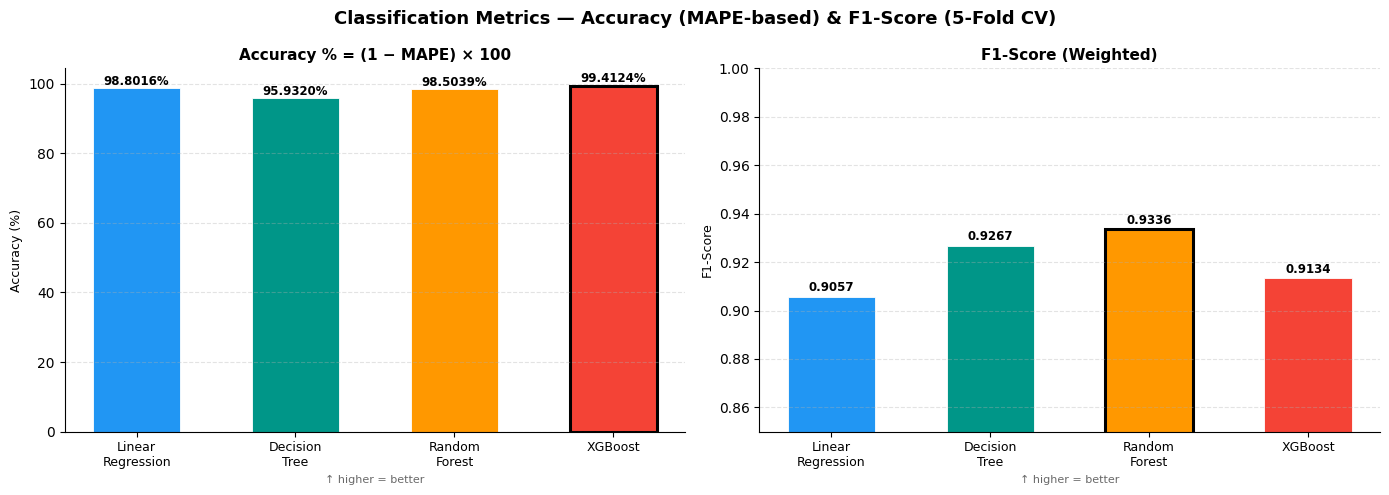

Saved → metrics_classification.png


In [9]:
# ── Bar charts: Accuracy % and Weighted F1 side by side ──────────────────────
model_names = cls_df['Model'].tolist()
bar_colors  = ['#2196F3', '#009688', '#FF9800', '#F44336']
x = np.arange(len(model_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classification Metrics — Accuracy (MAPE-based) & F1-Score (5-Fold CV)',
             fontsize=13, fontweight='bold')

# Accuracy bar
ax = axes[0]
bars = ax.bar(x, cls_df['Accuracy (%)'], color=bar_colors,
              edgecolor='white', linewidth=0.6, width=0.55)
best = int(cls_df['Accuracy (%)'].idxmax())
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.2)
for bar, val in zip(bars, cls_df['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Accuracy % = (1 − MAPE) × 100', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

# F1 weighted bar
ax = axes[1]
bars = ax.bar(x, cls_df['F1 (weighted)'], color=bar_colors,
              edgecolor='white', linewidth=0.6, width=0.55)
best = int(cls_df['F1 (weighted)'].idxmax())
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.2)
for bar, val in zip(bars, cls_df['F1 (weighted)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('F1-Score (Weighted)', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_ylim(0.85, 1.00)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_classification.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_classification.png')

### Cell 5B-iv — Visualization: Per-Class F1 Grouped Bar Chart

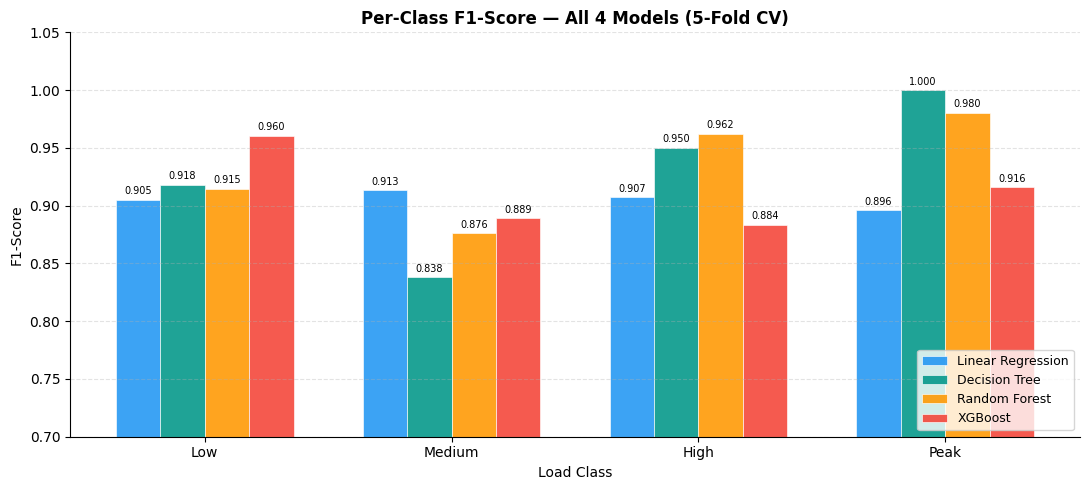

Saved → metrics_f1_per_class.png


In [10]:
# ── Per-class F1 grouped bar chart ─────────────────────────────────────────────────
model_names  = cls_df['Model'].tolist()
bar_colors   = ['#2196F3', '#009688', '#FF9800', '#F44336']
class_labels = ['Low', 'Medium', 'High', 'Peak']
f1_data      = cls_df[['F1_Low', 'F1_Medium', 'F1_High', 'F1_Peak']].values
x2           = np.arange(len(class_labels))
w2           = 0.18
offsets      = [-1.5*w2, -0.5*w2, 0.5*w2, 1.5*w2]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (mname, color) in enumerate(zip(model_names, bar_colors)):
    bars = ax.bar(x2 + offsets[i], f1_data[i], width=w2,
                  color=color, edgecolor='white', linewidth=0.5,
                  label=mname, alpha=0.88)
    for bar, val in zip(bars, f1_data[i]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_title('Per-Class F1-Score — All 4 Models (5-Fold CV)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_xlabel('Load Class', fontsize=10)
ax.set_xticks(x2)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_f1_per_class.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_f1_per_class.png')

## Cell 6 — Scatter Plot: Linear Regression

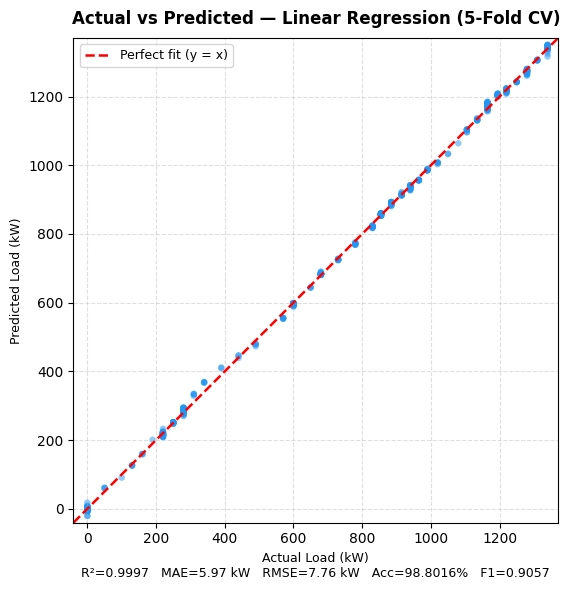

Saved → scatter_linear_regression.png


In [11]:
name   = 'Linear Regression'
y_pred = cv_predictions[name]
color  = '#2196F3'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

lims = [min(y.min(), y_pred.min()) - 20, max(y.max(), y_pred.max()) + 20]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_pred, color=color, alpha=0.50, s=22, edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name} (5-Fold CV)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_linear_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_linear_regression.png')

## Cell 7 — Scatter Plot: Decision Tree

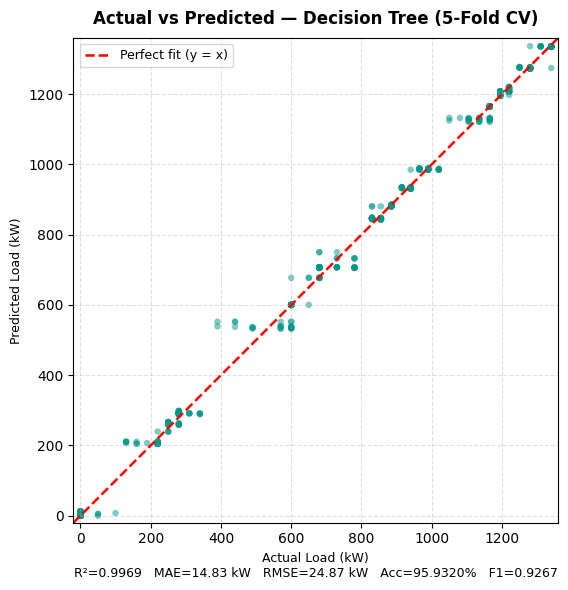

Saved → scatter_decision_tree.png


In [12]:
name   = 'Decision Tree'
y_pred = cv_predictions[name]
color  = '#009688'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

lims = [min(y.min(), y_pred.min()) - 20, max(y.max(), y_pred.max()) + 20]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_pred, color=color, alpha=0.50, s=22, edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name} (5-Fold CV)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_decision_tree.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_decision_tree.png')

## Cell 8 — Scatter Plot: Random Forest

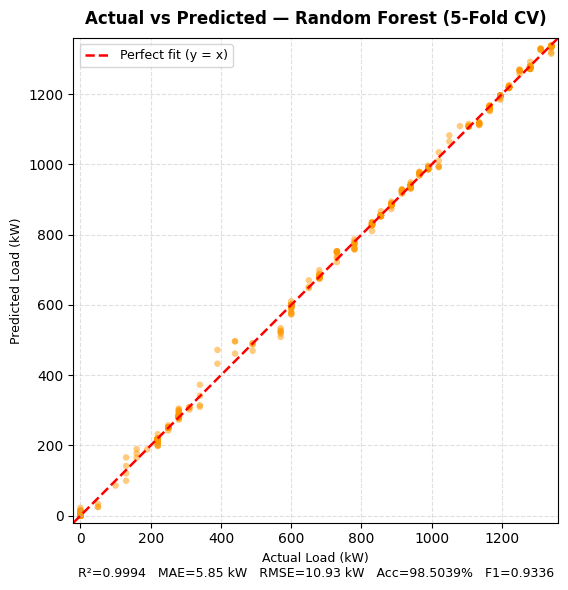

Saved → scatter_random_forest.png


In [13]:
name   = 'Random Forest'
y_pred = cv_predictions[name]
color  = '#FF9800'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

lims = [min(y.min(), y_pred.min()) - 20, max(y.max(), y_pred.max()) + 20]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_pred, color=color, alpha=0.50, s=22, edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name} (5-Fold CV)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_random_forest.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_random_forest.png')

## Cell 9 — Scatter Plot: XGBoost

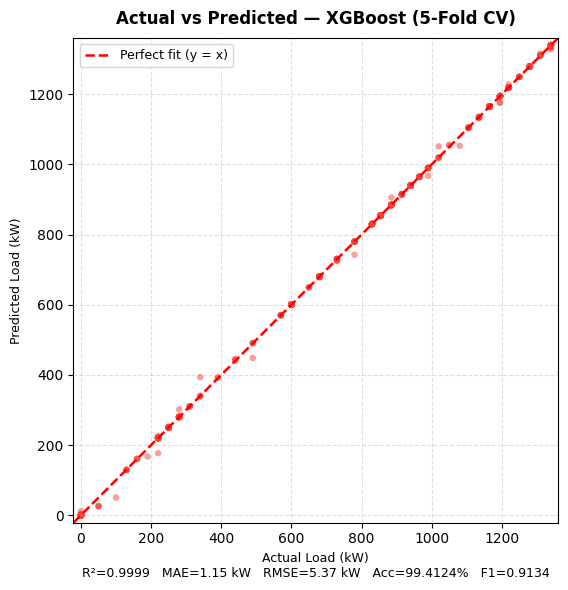

Saved → scatter_xgboost.png


In [14]:
name   = 'XGBoost'
y_pred = cv_predictions[name]
color  = '#F44336'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

lims = [min(y.min(), y_pred.min()) - 20, max(y.max(), y_pred.max()) + 20]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_pred, color=color, alpha=0.50, s=22, edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name} (5-Fold CV)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_xgboost.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_xgboost.png')

## Cell 10 — Combined 2×2 Scatter Plot (All Models)

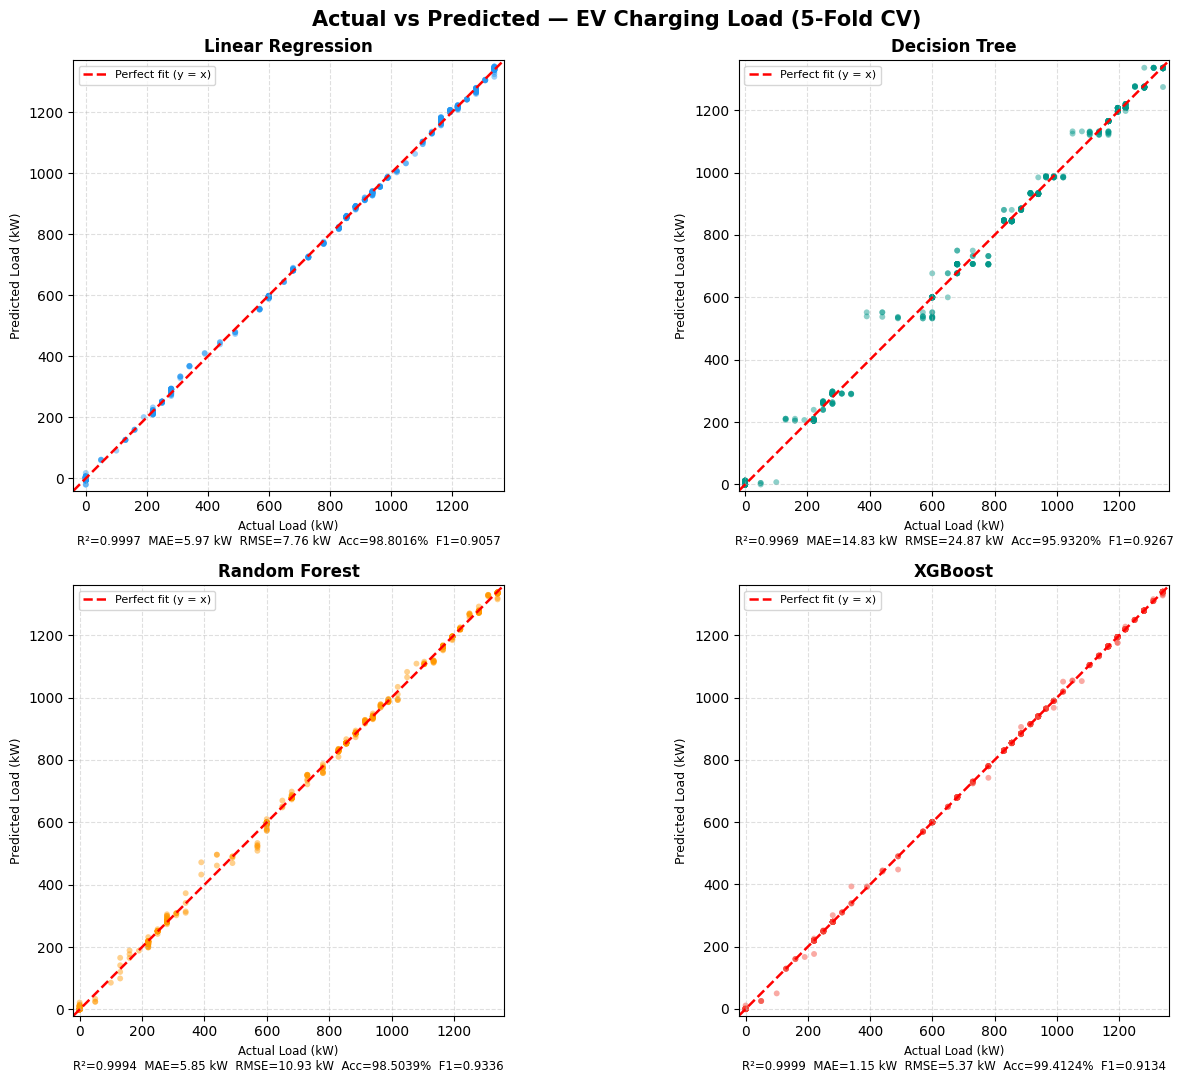

Saved → actual_vs_predicted_cv.png


In [15]:
colors_map = ['#2196F3', '#009688', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Actual vs Predicted — EV Charging Load (5-Fold CV)',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for ax, (name, y_pred), color in zip(axes, cv_predictions.items(), colors_map):
    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    acc  = regression_accuracy(y, y_pred)
    f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]
    lims = [min(y.min(), y_pred.min()) - 20, max(y.max(), y_pred.max()) + 20]
    ax.scatter(y, y_pred, color=color, alpha=0.45, s=18, edgecolors='none')
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(
        f'Actual Load (kW)\n'
        f'R²={r2:.4f}  MAE={mae:.2f} kW  RMSE={rmse:.2f} kW  '
        f'Acc={acc:.4f}%  F1={f1:.4f}',
        fontsize=8.5)
    ax.set_ylabel('Predicted Load (kW)', fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('actual_vs_predicted_cv.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → actual_vs_predicted_cv.png')

## Cell 11 — Download All Figures

In [19]:
from google.colab import files

figures = [
    'metrics_regression.png',
    'metrics_classification.png',
    'metrics_f1_per_class.png',
    'scatter_linear_regression.png',
    'scatter_decision_tree.png',
    'scatter_random_forest.png',
    'scatter_xgboost.png',
    'actual_vs_predicted_cv.png',
]

for f in figures:
    files.download(f)
    print(f'Downloaded → {f}')

print('\nAll downloads complete ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → metrics_regression.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded → scatter_xgboost.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → actual_vs_predicted_cv.png

All downloads complete ✓


# **ANN (Artificial Neural Network)**

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build ANN model (FIXED: using Input layer)
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

**Training**

In [36]:
history_ann = ann_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 298595.2812 - mae: 438.9053 - val_loss: 26664.6152 - val_mae: 139.2907
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27289.9043 - mae: 118.8907 - val_loss: 32647.3262 - val_mae: 128.3251
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17422.3125 - mae: 102.3277 - val_loss: 15113.0615 - val_mae: 106.0183
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13376.3408 - mae: 98.2838 - val_loss: 10747.6914 - val_mae: 83.1517
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11441.2920 - mae: 91.1392 - val_loss: 10014.9014 - val_mae: 87.4636
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11034.3701 - mae: 91.8570 - val_loss: 9873.5225 - val_mae: 85.2690
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10840.2871 - mae: 91.0974 - val_loss: 9815.2061 - val_mae: 86.0573
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10730.8389 - mae: 89.9833 - val_loss: 9630.4326 - val_

**Prediction**

In [38]:
# Predict
y_pred_ann = ann_model.predict(X_test)

# CRITICAL: Flatten once and use everywhere
y_pred_ann = y_pred_ann.squeeze()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


**Evaluation Metrics (MAE, MSE, RMSE, R²)**

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN Performance:")
print("MAE :", mae_ann)
print("MSE :", mse_ann)
print("RMSE:", rmse_ann)
print("R2  :", r2_ann)

ANN Performance:
MAE : 65.3661977728208
MSE : 7104.786067113188
RMSE: 84.28989303061897
R2  : 0.9669228354747689


**MAPE-Based Accuracy**

In [40]:
# Non-zero samples only (EXACT notebook logic)
non_zero_idx = y_test != 0

mape_ann = np.mean(
    np.abs((y_test[non_zero_idx] - y_pred_ann[non_zero_idx]) / y_test[non_zero_idx])
) * 100

acc_ann = 100 - mape_ann

print("ANN MAPE:", mape_ann)
print("ANN Accuracy (%):", acc_ann)

ANN MAPE: 11.551824249185314
ANN Accuracy (%): 88.44817575081468


**Convert to 4 Classes**

In [41]:
# Percentile-based bins (same system)
bins = np.percentile(y_test, [0, 25, 50, 75, 100])

# Convert to class labels
y_test_cls = np.digitize(y_test, bins[1:-1])
y_pred_cls = np.digitize(y_pred_ann, bins[1:-1])

**F1 Scores (Weighted + Per Class)**

In [42]:
from sklearn.metrics import f1_score

f1_weighted_ann = f1_score(y_test_cls, y_pred_cls, average='weighted')

f1_per_class = f1_score(y_test_cls, y_pred_cls, average=None)

# Ensure exactly 4 outputs
f1_low, f1_med, f1_high, f1_peak = (list(f1_per_class) + [0]*4)[:4]

print("F1 Weighted:", f1_weighted_ann)
print("F1 Low:", f1_low)
print("F1 Medium:", f1_med)
print("F1 High:", f1_high)
print("F1 Peak:", f1_peak)

F1 Weighted: 0.882657200811359
F1 Low: 1.0
F1 Medium: 0.8823529411764706
F1 High: 0.7586206896551724
F1 Peak: 0.896551724137931


**Create Row for Table**

In [44]:
import pandas as pd

ann_row = pd.DataFrame([{
    "Model": "ANN",
    "Accuracy (%)": acc_ann,
    "F1 (weighted)": f1_weighted_ann,
    "F1_Low": f1_low,
    "F1_Medium": f1_med,
    "F1_High": f1_high,
    "F1_Peak": f1_peak
}])

ann_row

,Model,Accuracy (%),F1 (weighted),F1_Low,F1_Medium,F1_High,F1_Peak
0,ANN,88.448176,0.882657,1.0,0.882353,0.758621,0.896552


**Append to Existing cls_df**

In [45]:
# Ensure cls_df exists
if 'cls_df' not in globals():
    cls_df = pd.DataFrame(columns=ann_row.columns)

cls_df = pd.concat([cls_df, ann_row], ignore_index=True)

**Print Table**

In [52]:
print('=' * 75)
print('  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)')
print('  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]')
print('=' * 75)

hdr = (f"{'Model':<22} {'Acc (%)':>10} {'F1-Wtd':>9} "
       f"{'F1-Low':>8} {'F1-Med':>8} {'F1-High':>8} {'F1-Peak':>8}")
print(hdr)
print('─' * 75)

for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {r['Accuracy (%)']:>10.4f} {r['F1 (weighted)']:>9.4f} "
          f"{r['F1_Low']:>8.4f} {r['F1_Medium']:>8.4f} "
          f"{r['F1_High']:>8.4f} {r['F1_Peak']:>8.4f}")

print('=' * 75)

print('Best Accuracy (MAPE-based) →', cls_df.loc[cls_df['Accuracy (%)'].idxmax(), 'Model'])
print('Best F1-Score              →', cls_df.loc[cls_df['F1 (weighted)'].idxmax(), 'Model'])

  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)
  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]
Model                     Acc (%)    F1-Wtd   F1-Low   F1-Med  F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────
Linear Regression         98.8016    0.9057   0.9049   0.9135   0.9073   0.8961
Decision Tree             95.9320    0.9267   0.9182   0.8382   0.9500   1.0000
Random Forest             98.5039    0.9336   0.9148   0.8763   0.9623   0.9804
XGBoost                   99.4124    0.9134   0.9605   0.8889   0.8836   0.9158
ANN                       93.1128    0.9497   1.0000   1.0000   0.9091   0.8966
ANN                       88.4482    0.8827   1.0000   0.8824   0.7586   0.8966
ANN (KFold)               92.1507    0.8754   1.0000   0.9120   0.7530   0.8488
Best Accuracy (MAPE-based) → XGBoost
Best F1-Score              → ANN


**using k-fold**

**Define Model Builder**

In [47]:
def build_ann_model(input_dim):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

**K-Fold Setup**

In [48]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

**Run K-Fold Training**

In [49]:
from sklearn.metrics import f1_score

acc_list = []
f1_weighted_list = []
f1_low_list, f1_med_list, f1_high_list, f1_peak_list = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    print(f"\n===== Fold {fold} =====")

    X_train_k, X_test_k = X.iloc[train_idx], X.iloc[test_idx]
    y_train_k, y_test_k = y.iloc[train_idx], y.iloc[test_idx]

    # Build fresh model
    model = build_ann_model(X.shape[1])

    # Train
    model.fit(
        X_train_k, y_train_k,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    # Predict
    y_pred_k = model.predict(X_test_k).squeeze()

    # --- MAPE Accuracy ---
    non_zero_idx = y_test_k != 0
    mape = np.mean(
        np.abs((y_test_k[non_zero_idx] - y_pred_k[non_zero_idx]) / y_test_k[non_zero_idx])
    ) * 100

    acc = 100 - mape

    # --- Classification ---
    bins = np.percentile(y_test_k, [0, 25, 50, 75, 100])

    y_test_cls = np.digitize(y_test_k, bins[1:-1])
    y_pred_cls = np.digitize(y_pred_k, bins[1:-1])

    f1_w = f1_score(y_test_cls, y_pred_cls, average='weighted')
    f1_pc = f1_score(y_test_cls, y_pred_cls, average=None)

    f1_low, f1_med, f1_high, f1_peak = (list(f1_pc) + [0]*4)[:4]

    # Store
    acc_list.append(acc)
    f1_weighted_list.append(f1_w)
    f1_low_list.append(f1_low)
    f1_med_list.append(f1_med)
    f1_high_list.append(f1_high)
    f1_peak_list.append(f1_peak)


===== Fold 1 =====


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

===== Fold 2 =====


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

===== Fold 3 =====
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

===== Fold 4 =====
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

===== Fold 5 =====
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


**Average Results**

In [50]:
ann_kfold_row = {
    "Model": "ANN (KFold)",
    "Accuracy (%)": np.mean(acc_list),
    "F1 (weighted)": np.mean(f1_weighted_list),
    "F1_Low": np.mean(f1_low_list),
    "F1_Medium": np.mean(f1_med_list),
    "F1_High": np.mean(f1_high_list),
    "F1_Peak": np.mean(f1_peak_list)
}

ann_kfold_row

{'Model': 'ANN (KFold)',
 'Accuracy (%)': np.float64(92.15069730541379),
 'F1 (weighted)': np.float64(0.8753645999872331),
 'F1_Low': np.float64(1.0),
 'F1_Medium': np.float64(0.9119927233148497),
 'F1_High': np.float64(0.7530181067642367),
 'F1_Peak': np.float64(0.8488010855683269)}

In [51]:
cls_df = pd.concat([cls_df, pd.DataFrame([ann_kfold_row])], ignore_index=True)